## Calculating a Life Cycle Assessment by Hand

📖 See also [Heijungs & Suh (2002), Section 2](https://doi.org/10.1007/978-94-015-9900-9)  
💻 Brightway ["From the Ground Up" Teaching Materials](https://github.com/brightway-lca/from-the-ground-up)

### Example System 1 (by Hand)

First, we consider a simple example system, consisting of three production processes:

| index | process |
|-------|---------|
| 1 | vehicle production |
| 2 | metals production  |
| 3 | natural gas production |

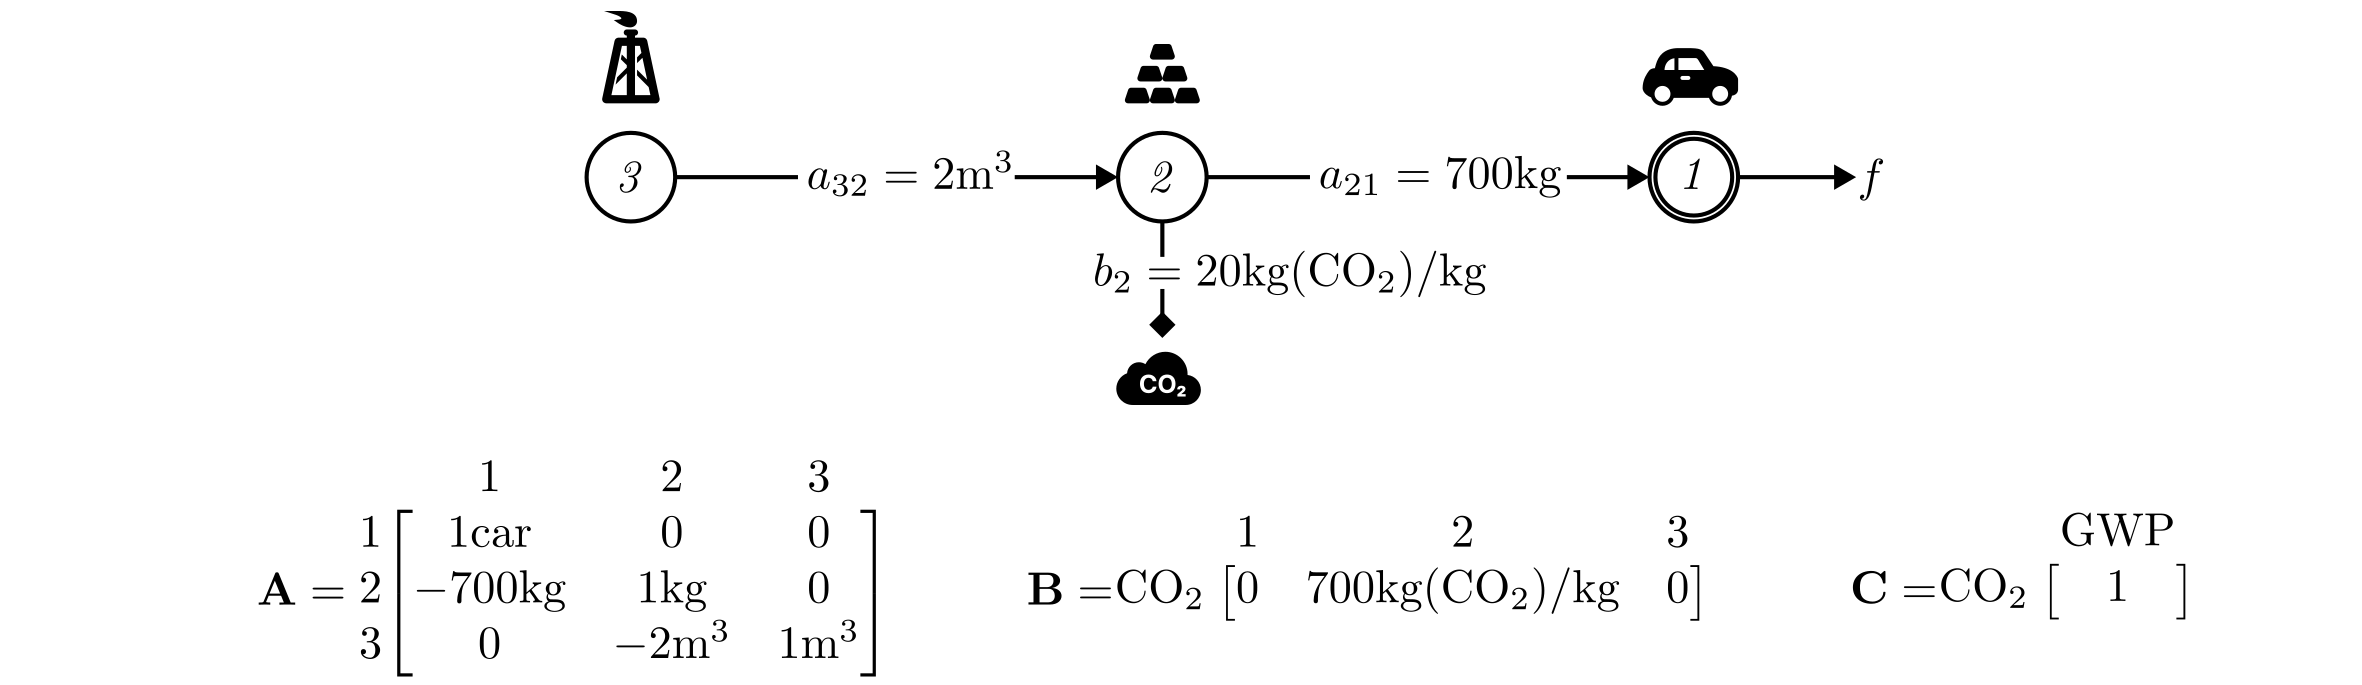

We have collected the information about flows between processes and their associated emissions in three matrices:

| matrix | name | dimension |
|--------|------|-----------|
| $\mathbf{A}$ | technosphere matrix | products $\times$ processes
| $\mathbf{B}$ | biosphere matrix  | environmental burdens $\times$ processes
| $\mathbf{C}$ | characterization matrix | environmental impact factor $\times$ environmental burdens

Matrix coefficients are defined as:

\begin{align}
    (\mathbf{A})_{ij} = a_{ij} &= (+\text{production}/-\text{consumption}) \text{ of product $i$ by process $j$} \\
    (\mathbf{B})_{ij} = b_{ij} &= \text{emission of environmental burden $i$ by process $j$} \\
    (\mathbf{C})_{ij} = c_{ij} &= \text{characterization factor for impact category $i$ of environmental burden $j$}
\end{align}

However, here we can still calculate the total CO$_2$ emissions of the example system easily by hand.

If we assume a final demand of one car $f_1=1$, we can write simply $g = 700 \text{kg} \times 20 \text{kg(CO$_2$)/kg} = 1'400\text{kg(CO$_2$)}$.

### Example System 2 (with NumPy)

Of course, in reality many supply chains are much more complex. Many will also contain loops. This means that processes depend on each other.

Consider this slight modification of the first example sytstem.  
Here, natural gas production now (3) requires a small input of metals production (2).

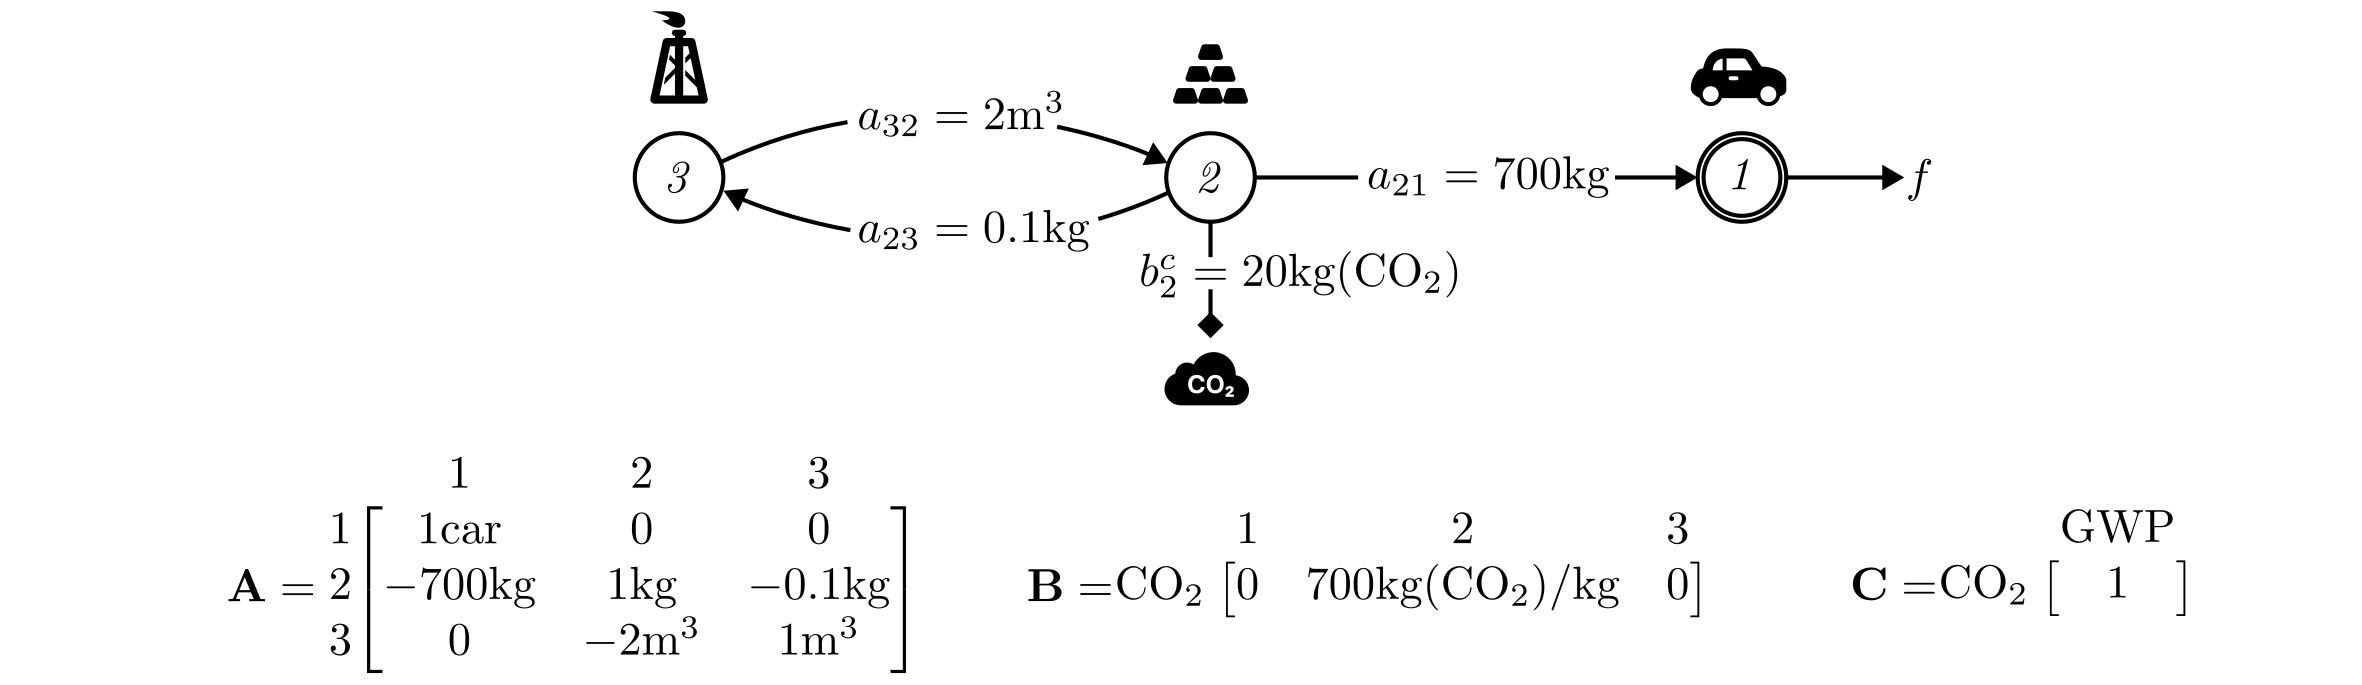

We can see that this has also been recorded in the matrix $\mathbf{A}$, where we now have a non-zero coefficient $a_{23}=-0.1\text{kg}$.  
Calculating total CO₂ emissions here is now more difficult. We must first determine how much of each process is required to satisfy the final demand of one car.

For this, we must solve a linear system of equations. We can write it as:

\begin{align}
f_1 &= a_{11} s_1 + a_{12} s_2 + a_{13} s_3 \\
f_2 &= a_{21} s_1 + a_{22} s_2 + a_{23} s_3 \\
f_3 &= a_{31} s_1 + a_{32} s_2 + a_{33} s_3 \\
\end{align}

Here, $s$ is a scaling coefficient that determines how much of each process must produced to satify final demand. Looking at the first of these equations, we find that $f_1=1=1 \times s_1 + 0 \times s_2 + 0 \times s_3$. To satisfy a final demand of one car, the vehicle manufacturing process must "run" just once. 

This also means we have already found the first scaling coefficient $s_1=1$.  
To find the other scaling factors, we can write the above equations in matrix form as

\begin{equation}
 \begin{bmatrix} a_{11} & a_{12} & a_{13} \\ a_{21} & a_{22} & a_{23} \\ a_{31} & a_{32} & a_{33} \end{bmatrix} \begin{bmatrix} s_{1} \\ s_{2} \\ s_{3} \end{bmatrix}  = \begin{bmatrix} f_{1} \\ f_{2} \\ f_{3} \end{bmatrix} 
\end{equation}

or, in short

\begin{equation}
\mathbf{A}\vec{s} = \vec{f}
\end{equation}

Of course, we are interested in the scaling vector $\vec{s}$, so we re-write the above equation to read

\begin{equation}
\vec{s} = \mathbf{A}^{-1} \vec{f}
\end{equation}

The scaling vector $\vec{s}$ now tells us how much of each process is required to satisfy the final demand. Now, we can use this information to determine the total CO₂ emissions $g$ of the system. We simply have to multiply each scaling coefficient with the associated CO₂ emissions intensity of each process, and sum them up.

\begin{equation}
    g = b_{1} s_1 + b_{2} s_2 + b_{3} s_3
\end{equation}

For a general case, we can again write this in matrix form as

\begin{equation}
    \vec{g} = \mathbf{B} \vec{s} = \mathbf{B} \mathbf{A}^{-1} \vec{f}
\end{equation}

Now, let's calculate this using the [NumPy Python package](https://numpy.org/doc/stable/index.html).

In [1]:
import numpy as np

In [ ]:
A = np.array([
    [1,    0,    0],
    [-700, 1, -0.1],
    [0,   -3,    1]
])
B = np.array([[0, 20, 0]])
f = np.array([
    [1],
    [0],
    [0]
])

First, let's calculate how much of each process is required to satisfy a final demand of one car:

In [3]:
np.linalg.inv(A) @ f

array([[1.e+00],
       [1.e+03],
       [3.e+03]])

Here, [`np.linalg.inv()` is the inverse of a matrix](https://numpy.org/doc/stable/reference/generated/numpy.linalg.inv.html) and [@ is the matrix-multiplication operator](https://numpy.org/doc/stable/reference/generated/numpy.matmul.html).

That is our scaling vector $\vec{s}$:

\begin{equation}
    \vec{s} = \begin{bmatrix} 1 \text{car} \\ 875 \text{kg} \\ 1'750 \text{m}^3 \end{bmatrix}
\end{equation}

Now, let's calculate total CO₂ emissions $g$:

In [4]:
B @ np.linalg.inv(A) @ f

array([[20000.]])

The environmental burdens $\vec{g}$ are often called the _inventory_. We can now also _characterize_ the inventory. For instance, Methane (CH₄) has a much higher global warming potential than CO₂. To account for this, we can therefore multiply the inventory with a characterization factor. For instance, the IPCC "GWP100" impact assessment method metric has factors 1 for CO₂ and 28 for CH₄.

In the example system, we only have CO₂ emissions, so the characterization factor is simply 1 and the characterization matrix $\mathbf{C} can be written as:

\begin{equation}
    \mathbf{C} = \begin{bmatrix} 1 \end{bmatrix}
\end{equation}

In [1]:
C @ (B @ np.linalg.inv(A) @ f)

NameError: name 'C' is not defined

🌿 Congratulations! You have just calculated a complete life cycle assessment using a matrix-based approach!

### Example System 2 (with Brightway)

First, we import some relevant Brightway packages. `bw2data` is used to manage databases and `bw2calc` allows us to perform calculations. `stats_arrays` is used to handle uncertainty in data.

In [5]:
import bw2data as bd
import bw2calc as bc
import stats_arrays as sa

/Users/michaelweinold/venv/bw25/lib/python3.12/site-packages/bw2calc/__init__.py:50: UserWarning: 
It seems like you have an ARM architecture, but haven't installed scikit-umfpack:

    https://pypi.org/project/scikit-umfpack/

Installing it could give you much faster calculations.

  warnings.warn(UMFPACK_WARNING)


First, we create a Brightway `project`. This data object can contain multiple `Databases`, is completely self-contained, and independent of other projects.  
This independence can lead to data duplication, but helps keep each project safe from the changes in the others.

We start in the `default` project:

In [6]:
bd.projects.current

'default'

It is good practice to switch to a new project:

In [7]:
bd.projects.set_current("vehicle_manufacting")
bd.projects.current

'vehicle_manufacting'

⚠️ It can be very convenient to just delete a project and start over if exotic error messages start appearing.  
To delete the "vehicle manufacting" project, just set `I_SCREWED_UP==True`:

In [9]:
I_SCREWED_UP = True
if I_SCREWED_UP == True:
    try:
        bd.projects.delete_project("vehicle_manufacting", delete_dir=True)
        bd.projects.set_current("vehicle_manufacting")
    except ValueError:
        pass

Now, we create a `Database` object for our example system.  
A `Database` contains all processes of a system, along with their inputs, outputs, and emissions.  
Here, we create a database called "Demo" and add our three processes to it.

In [11]:
db = bd.Database("Demo")
db.register()

We can check if the database has been successfully created:

In [13]:
bd.databases

Databases dictionary with 1 object(s):
	Demo

In the [language of graph theory](https://en.wikipedia.org/wiki/Graph_theory), the processes are _nodes_ and flows between them and to the environment are _edges_.  
We must therefore create our three process nodes. We start with the vehicle manufacturing process 1, which we here designate `car`:

In [14]:
car = db.new_node(
    name="car", # the 'name' field does not have to be unique
    code="car", # the 'code' field, however, should be unique
    unit="number", # this can be any unit like 'kg', 'kWh', etc.
    type=bd.labels.chimaera_node_default, # this way we do not need to create another node for the "car" product
)
car.save()

In [15]:
gas = db.new_node(
    name="gas",
    code="gas",
    unit="m3",
    type=bd.labels.chimaera_node_default,
)
gas.save()

In [16]:
metal = db.new_node(
    name="metal",
    code="metal",
    unit="kg",
    type=bd.labels.chimaera_node_default,
)
metal.save()

Environmental burdens, such as CO2, are also represented as nodes in the graph. Here, the `type` is of kind `biosphere_node_default`.

In [17]:
co2 = db.new_node(
    name="Carbon Dioxide", 
    context=("air",),
    tags={"CAS Number": "124-38-9"},
    unit="kg",
    type=bd.labels.biosphere_node_default,
)
co2.save()

Now, we need to create edges between the nodes:

In [18]:
car.new_edge(
    amount=700.0, 
    type=bd.labels.consumption_edge_default,
    input=metal
).save()

In [19]:
metal.new_edge(
    amount=3.0, 
    type=bd.labels.consumption_edge_default,
    input=gas
).save()

In [20]:
gas.new_edge(
    amount=0.1, 
    type=bd.labels.consumption_edge_default,
    input=metal
).save()

We must also add the CO₂ emissions from metals production:

In [21]:
metal.new_edge(
    amount=20.0,
    type=bd.labels.biosphere_edge_default,
    input=co2,
).save()

Finally, we must define a method to _characterize_ the CO₂ emissions. Here, we use the IPCC "GWP100" method. Per definition, 1 kg of CO₂ has a global warming potential of 1 kg CO₂-equivalent:

In [23]:
ipcc = bd.Method(('IPCC',))
ipcc.write([
    (co2, {'amount': 1.0}),
])

Now, we can set up the life cycle assessment inventory calculation $\vec{s} = \mathbf{A}^{-1} \vec{f}$:

In [25]:
functional_unit, data_objs, _ = bd.prepare_lca_inputs(
    demand={car: 1},
    method=("IPCC",),
)

In [26]:
lca = bc.LCA(demand=functional_unit, data_objs=data_objs)
lca.lci()

The _inventory problem_ has now been solved. Brightway stores result in an inventory matrix $\mathbf{G}$, where each row corresponds to a an environmental burden and each column to a process. Each entry $g_{ij}$ indicates how much of environmental burden $i$ is emitted by process $j$ per unit of final demand.

In [29]:
lca.inventory.todense()

matrix([[    0.        ,     0.        , 20000.00012772]])

Like before, we can now characterize the inventory:

In [31]:
lca.lcia()

The results can now be interpreted. We can show a summary of the results by converting the characterized inventory to a `pandas` `DataFrame`:

In [32]:
lca.to_dataframe()

,row_index,col_index,amount,row_id,col_id,row_database,row_code,row_name,row_location,row_unit,row_type,row_categories,row_product,col_database,col_code,col_name,col_location,col_unit,col_type,col_reference_product
0,0,2,20000.000128,219781417669828608,219781416075993088,Demo,77b6efe902824f678ef92b461fb537e3,Carbon Dioxide,GLO,kg,emission,None,None,Demo,metal,metal,GLO,kg,processwithreferenceproduct,None
